In [1]:
!pip install transformers opencv-python pillow matplotlib

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from transformers import TrOCRProcessor, VisionEncoderDecoderModel

In [3]:
processor = TrOCRProcessor.from_pretrained("microsoft/trocr-base-handwritten")
model = VisionEncoderDecoderModel.from_pretrained("microsoft/trocr-base-handwritten")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

(np.float64(-0.5), np.float64(1599.5), np.float64(703.5), np.float64(-0.5))

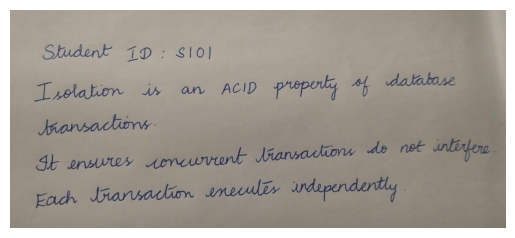

In [7]:
image = cv2.imread(image_path)

plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

(np.float64(-0.5), np.float64(1599.5), np.float64(703.5), np.float64(-0.5))

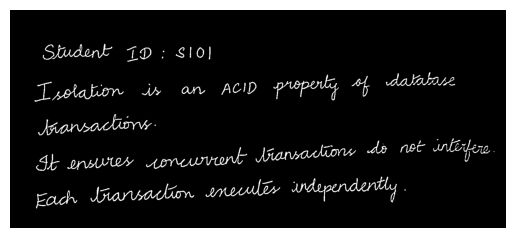

In [8]:
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# remove noise
blur = cv2.GaussianBlur(gray,(5,5),0)

# adaptive threshold
thresh = cv2.adaptiveThreshold(
    blur,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY_INV,
    15,
    10
)

plt.imshow(thresh, cmap="gray")
plt.axis("off")

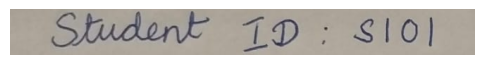

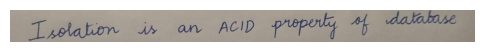

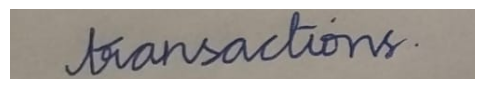

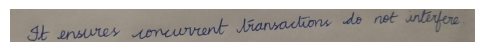

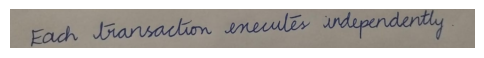

In [9]:
kernel = np.ones((8,120), np.uint8)

dilated = cv2.dilate(thresh, kernel, iterations=1)

contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# 🔹 sort contours from top to bottom
contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[1])

line_images = []

for cnt in contours:

    x,y,w,h = cv2.boundingRect(cnt)

    if h > 40:
        line = image[y:y+h, x:x+w]
        line_images.append(line)

        plt.figure(figsize=(6,2))
        plt.imshow(cv2.cvtColor(line, cv2.COLOR_BGR2RGB))
        plt.axis("off")

In [10]:
from sentence_transformers import SentenceTransformer

similarity_model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [17]:
model_answer = """
Isolation is an ACID property of database transactions.
It ensures that concurrent transactions do not interfere with each other.
Each transaction executes independently.
"""

In [22]:
def evaluate_answer(image_path):

    import cv2, re, numpy as np
    from PIL import Image
    import matplotlib.pyplot as plt
    from sentence_transformers import util

    # load image
    image = cv2.imread(image_path)

    plt.figure(figsize=(6,4))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")

    # preprocessing
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray,(5,5),0)

    thresh = cv2.adaptiveThreshold(
        blur,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        15,
        10
    )

    # detect text lines
    kernel = np.ones((8,120), np.uint8)
    dilated = cv2.dilate(thresh, kernel, iterations=1)

    contours, _ = cv2.findContours(dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    contours = sorted(contours, key=lambda c: cv2.boundingRect(c)[1])

    line_images = []

    for cnt in contours:
        x,y,w,h = cv2.boundingRect(cnt)

        if h > 40:
            line = image[y:y+h, x:x+w]
            line_images.append(line)

    # ===== OCR (Your Accurate OCR Block) =====

    recognized_lines = []

    for line in line_images:

        pil_line = Image.fromarray(line)

        pil_line = pil_line.resize((384,128))

        pixel_values = processor(images=pil_line, return_tensors="pt").pixel_values

        generated_ids = model.generate(pixel_values)

        text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

        recognized_lines.append(text)

    print("\nRecognized Text:\n")

    for t in recognized_lines:
        print(t)

    # combine text
    full_text = " ".join(recognized_lines)

    # ===== Student ID Detection =====

    student_match = re.search(r"S\d+", full_text)

    if student_match:
        student_id = student_match.group()
    else:
        student_id = "Unknown"

    print("\nStudent Verified:", student_id)

    # ===== Clean Answer =====

    clean_answer = re.sub(r'[^a-zA-Z ]',' ', full_text)
    clean_answer = clean_answer.lower()

    # ===== Semantic Similarity =====

    emb1 = similarity_model.encode(model_answer, convert_to_tensor=True)
    emb2 = similarity_model.encode(clean_answer, convert_to_tensor=True)

    similarity = util.cos_sim(emb1, emb2).item()

    print("\nSimilarity Score:", similarity)

    # ===== Grading =====

    marks = round(similarity * 6)

    print("\nMarks Awarded:", marks, "/6")

    # ===== Feedback =====

    keywords = ["isolation","acid","transactions","concurrent","independently"]

    missing = []

    for word in keywords:
        if word not in clean_answer:
            missing.append(word)

    print("\nFeedback:")

    if missing:
        print("Student missed concepts:", missing)
    else:
        print("Excellent answer. All key concepts covered.")

Saving WhatsApp Image 2026-03-13 at 10.48.10 PM.jpeg to WhatsApp Image 2026-03-13 at 10.48.10 PM (2).jpeg

Recognized Text:

Student ID :S101.
Isolation is an ACID property of database
transactions .
It ensures concurrent transactions do not interfere .
Each transaction executes independently .

Student Verified: S101

Similarity Score: 0.8003064393997192

Marks Awarded: 5 /6

Feedback:
Excellent answer. All key concepts covered.


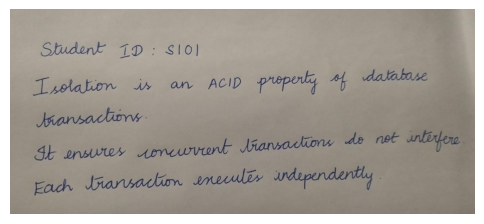

In [26]:
from google.colab import files
uploaded = files.upload()

image_path = list(uploaded.keys())[0]

evaluate_answer(image_path)